# Modelo XGBoost — Predicción del precio de Airbnb Madrid

Notebook de entrenamiento y evaluación del modelo XGBoost con optimización de hiperparámetros mediante Optuna.

**Pipeline:** Carga → Limpieza → Feature Engineering → Preprocesamiento → Optimización (Optuna) → Entrenamiento → Evaluación → Guardado del modelo

## 1. Imports

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import optuna
from scipy import stats
from scipy.special import inv_boxcox
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import haversine_distances
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Silenciar logs de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Carga y limpieza de datos

In [2]:
df = pd.read_csv("df_precios.csv")

# Eliminar columnas irrelevantes
cols_to_drop = ["id", "name", "host_id", "host_name", "last_review", "license"]
df = df.drop(cols_to_drop, axis=1, errors='ignore')

# Eliminar duplicados y nulos
df = df.drop_duplicates()
df = df.dropna()

print(f"Dataset listo: {df.shape}")

Dataset listo: (16923, 13)


## 3. Feature Engineering

In [3]:
# Ratio de disponibilidad anual (0-1)
df['availability_ratio'] = df['availability_365'] / 365

# Anfitrión profesional (más de 1 propiedad)
df['professional_host'] = (df['calculated_host_listings_count'] > 1).astype(int)

print("✅ availability_ratio creada")
print("✅ professional_host creada")

✅ availability_ratio creada
✅ professional_host creada


## 4. Separación de variables predictoras y objetivo

In [4]:
X = df.drop("price", axis=1)
y = df["price"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (16923, 14)
Dimensión de y: (16923,)


## 5. División Train / Test (80% / 20%)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:       ", X_test.shape)

Tamaño entrenamiento: (13538, 14)
Tamaño prueba:        (3385, 14)


## 6. Preprocesamiento

### 6.1 Transformación de la variable licencia (alta cardinalidad)

In [6]:
# Convertimos license en binaria: tiene licencia (0) o no (1)
X_train["license_binary"] = (X_train["license;"] == ";").astype(int)
X_train = X_train.drop(columns="license;")

X_test["license_binary"] = (X_test["license;"] == ";").astype(int)
X_test = X_test.drop(columns="license;")

### 6.2 Definición de columnas por tipo

In [7]:
col_dummies = ['neighbourhood_group', 'neighbourhood']

### 6.3 One-Hot Encoding de variables categóricas

In [8]:
X_train = pd.get_dummies(X_train, columns=col_dummies, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=col_dummies, drop_first=True)

# Alinear columnas train/test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Dimensión X_train después de encoding:", X_train.shape)
print("Dimensión X_test después de encoding: ", X_test.shape)

Dimensión X_train después de encoding: (13538, 159)
Dimensión X_test después de encoding:  (3385, 159)


### 6.4 Codificación ordinal de room_type

In [9]:
mapeo_habitacion = {"Hotel room": 2, "Entire home/apt": 3, "Private room": 1, "Shared room": 0}
X_train["room_type"] = X_train["room_type"].map(mapeo_habitacion)
X_test["room_type"]  = X_test["room_type"].map(mapeo_habitacion)

### 6.5 Distancia al centro de Madrid (Haversine)

In [10]:
madrid_center = np.radians([[40.4168, -3.7038]])

# Train
coords_train = np.radians(X_train[["latitude", "longitude"]])
X_train["distance_to_center_km"] = haversine_distances(coords_train, madrid_center) * 6371
X_train = X_train.drop(columns=["latitude", "longitude"])

# Test
coords_test = np.radians(X_test[["latitude", "longitude"]])
X_test["distance_to_center_km"] = haversine_distances(coords_test, madrid_center) * 6371
X_test = X_test.drop(columns=["latitude", "longitude"])

print("✅ distance_to_center_km creada")

✅ distance_to_center_km creada


### 6.6 Transformación logarítmica de variables numéricas sesgadas

In [11]:
columnas_log = ['reviews_per_month', 'calculated_host_listings_count',
                'distance_to_center_km', 'number_of_reviews', 'minimum_nights']

X_train[columnas_log] = X_train[columnas_log].apply(np.log1p)
X_test[columnas_log]  = X_test[columnas_log].apply(np.log1p)

print("✅ Transformación log aplicada a:", columnas_log)

✅ Transformación log aplicada a: ['reviews_per_month', 'calculated_host_listings_count', 'distance_to_center_km', 'number_of_reviews', 'minimum_nights']


### 6.7 Escalado con StandardScaler

Nota: XGBoost no requiere escalado, pero se aplica para mantener consistencia con el pipeline.

In [12]:
threshold = 10
high_cardinality = [col for col in X_train.columns if X_train[col].nunique() > threshold]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[high_cardinality]),
                               columns=high_cardinality, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test[high_cardinality]),
                               columns=high_cardinality, index=X_test.index)

X_train[high_cardinality] = X_train_scaled[high_cardinality]
X_test[high_cardinality]  = X_test_scaled[high_cardinality]

print("✅ Escalado aplicado. Variables escaladas:", len(high_cardinality))

✅ Escalado aplicado. Variables escaladas: 8


### 6.9 Transformación Box-Cox de la variable objetivo

In [13]:
y_train_bc, lambda_bc = stats.boxcox(y_train)
y_test_bc = stats.boxcox(y_test, lmbda=lambda_bc)

print(f"✅ Box-Cox aplicado. Lambda: {lambda_bc:.4f}")

✅ Box-Cox aplicado. Lambda: -0.1261


In [16]:
import joblib
from scipy.special import inv_boxcox
import pandas as pd
import matplotlib.pyplot as plt

modelo_lr = joblib.load(r"C:\Users\javie\Desktop\datascience\BOOTCAMP DATA SCIENCE REPOSITORIO\madrid-airbnb-price-prediction\src\models\modelo_airbnb_lr.pkl")
lr = modelo_lr["model"]
lambda_bc = modelo_lr["lambda_bc"]
features_lr = modelo_lr["features"]
y_pred_lr_bc = lr.predict(X_test[features_lr])
y_pred_lr_real = inv_boxcox(y_pred_lr_bc, lambda_bc)

mae_baseline  = mean_absolute_error(y_test, y_pred_lr_real)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lr_real))
r2_baseline   = r2_score(y_test_bc, y_pred_lr_bc)

print("📊 Baseline")
print(f"MAE:  {mae_baseline:.2f} €")
print(f"RMSE: {rmse_baseline:.2f} €")
print(f"R²:   {r2_baseline:.4f}")

📊 Baseline
MAE:  68.93 €
RMSE: 392.62 €
R²:   0.4832


✅ Modelos cargados correctamente.
📊 Ensemble (LR [+ XGB]) - Escala REAL €
MAE:  58.07 €
RMSE: 356.41 €
R²:   0.6418


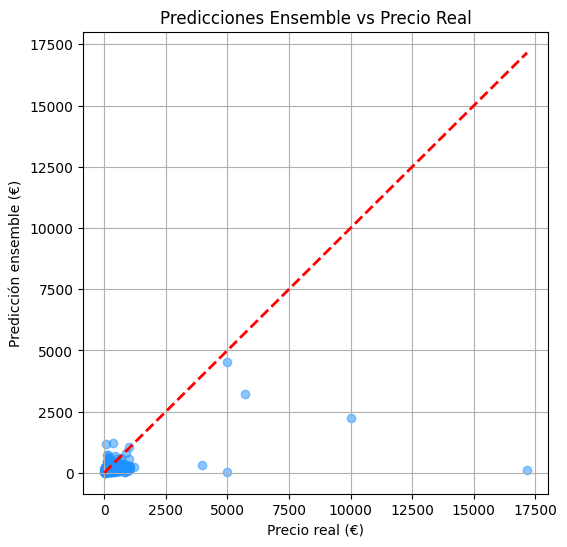

In [17]:


# Cargar Linear Regression


# Cargar XGBoost
modelo_xgb = joblib.load(r"C:\Users\javie\Desktop\datascience\BOOTCAMP DATA SCIENCE REPOSITORIO\madrid-airbnb-price-prediction\src\models\modelo_airbnb_xg.pkl")
xgb = modelo_xgb["model"]
features_xgb = modelo_xgb["features"]
lambda_bc_xgb = modelo_xgb["lambda_bc"]

modelo_rf = joblib.load(r"C:\Users\javie\Desktop\datascience\BOOTCAMP DATA SCIENCE REPOSITORIO\madrid-airbnb-price-prediction\src\models\modelo_airbnb_rf.pkl")
rf = modelo_rf["model"]
features_rf = modelo_rf["features"]
lambda_bc_rf = modelo_rf["lambda_bc"]

modelo_lgbm = joblib.load(r"C:\Users\javie\Desktop\datascience\BOOTCAMP DATA SCIENCE REPOSITORIO\madrid-airbnb-price-prediction\src\models\modelo_airbnb_lgbm.pkl")
lgbm = modelo_lgbm["model"]
features_lgbm = modelo_lgbm["features"]
lambda_bc_lgbm = modelo_lgbm["lambda_bc"]

print("✅ Modelos cargados correctamente.")

# --- 2️⃣ Predicción ---
# Suponiendo que X_test ya está definido en tu nuevo notebook


y_pred_xg_bc = xgb.predict(X_test[features_xgb])
y_pred_xg_real = inv_boxcox(y_pred_xg_bc, lambda_bc_xgb)

y_pred_rf_bc = rf.predict(X_test[features_rf])
y_pred_rf_real = inv_boxcox(y_pred_rf_bc, lambda_bc_rf)

y_pred_lgbm_bc = lgbm.predict(X_test[features_lgbm])
y_pred_lgbm_real = inv_boxcox(y_pred_lgbm_bc, lambda_bc_lgbm)

# Si tuvieras XGB, predicción también y luego media:
# y_pred_xgb_bc = modelo_xgb["model"].predict(X_test[features_xgb])
# y_pred_xgb_real = inv_boxcox(y_pred_xgb_bc, modelo_xgb["lambda_bc"])
# y_pred_ensemble = (y_pred_lr_real + y_pred_xgb_real) / 2

# Si solo LR, ensemble = predicción LR
y_pred_ensemble = (y_pred_rf_real + y_pred_xg_real +y_pred_lgbm_real )/3
y_pred_ensemble_bc = (y_pred_xg_bc+y_pred_rf_bc+y_pred_lgbm_bc)/3
# --- 3️⃣ Evaluación ---
# Suponiendo que y_test_real ya está transformado de Box-Cox
mae  = mean_absolute_error(y_test, y_pred_ensemble)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
r2   = r2_score(y_test_bc, y_pred_ensemble_bc)

print("📊 Ensemble (LR [+ XGB]) - Escala REAL €")
print(f"MAE:  {mae:.2f} €")
print(f"RMSE: {rmse:.2f} €")
print(f"R²:   {r2:.4f}")

# --- 4️⃣ Gráfica predicciones vs reales ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ensemble, alpha=0.5, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel("Precio real (€)")
plt.ylabel("Predicción ensemble (€)")
plt.title("Predicciones Ensemble vs Precio Real")
plt.grid(True)
plt.show()

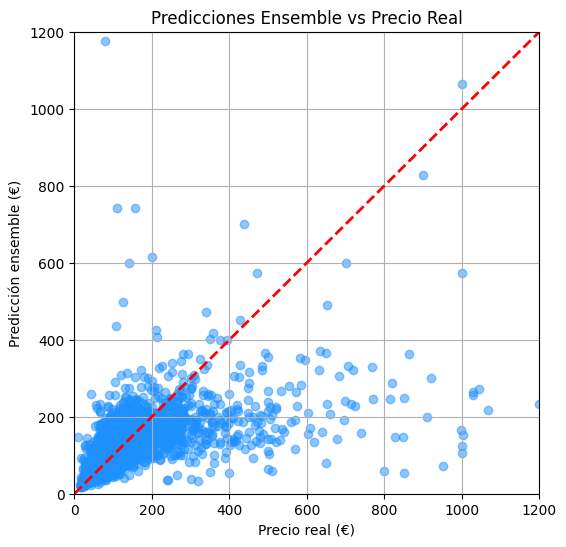

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_ensemble, alpha=0.5, color='dodgerblue')

# Línea diagonal perfecta
plt.plot([0, 1200],
         [0, 1200],
         'r--', lw=2)

plt.xlim(0, 1200)
plt.ylim(0, 1200)

plt.xlabel("Precio real (€)")
plt.ylabel("Predicción ensemble (€)")
plt.title("Predicciones Ensemble vs Precio Real")
plt.grid(True)

plt.show()